# Notebook Setup

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.stats as stats

# Portfolio Setup

In [2]:
tickers = ['AAPL', 'TSLA', 'MSFT', 'META', 'AMZN', 'GOOGL', 'NVDA'] #Ticker der MAG7 
start_capital = 100000

In [3]:
data = yf.download(tickers, start="2016-04-01", end="2026-04-01")['Close']

[*********************100%***********************]  7 of 7 completed


In [4]:
#Berechnung der täglichen Renditen (diskret und logarithmisch)
returns_discrete = data.pct_change().dropna()
returns_log = np.log(data / data.shift(1)).dropna()

#Portfolio-Gewichtung
weights = np.array([1/len(tickers)] * len(tickers)) #1/7 Gewichtung für jedes Asset

#Berechnung der Portfolio-Renditen
portfolio_returns_discrete = returns_discrete.dot(weights)
portfolio_returns_log = returns_log.dot(weights)



In [5]:
portfolio_returns_discrete.tail()

Date
2026-03-25    0.007628
2026-03-26   -0.031970
2026-03-27   -0.027635
2026-03-30   -0.001346
2026-03-31    0.045284
dtype: float64

# Brechnung 1-Tages-Risikomodelle 

In [6]:

# ==========================================
# Vorbereitung für Phase 2
# ==========================================
# Wir wählen ein Konfidenzniveau von 95% (wie in euren Folien oft als Standard genutzt)
# Das bedeutet, wir betrachten das 5% Quantil (die schlimmsten 5% der Fälle)
alpha = 0.05 
z_score = stats.norm.ppf(alpha) # Z-Wert für 5% in der Standardnormalverteilung (ca. -1.645)

print("\n--- Phase 2: 1-Tages Risikomodelle (100.000 EUR Portfolio) ---")

# ==========================================
# Schritt 2.1: Gaussian VaR (Standard Normalverteilung)
# ==========================================
# Wir nehmen an, die diskreten Renditen sind normalverteilt[cite: 278].
mu_norm = portfolio_returns_discrete.mean()
sigma_norm = portfolio_returns_discrete.std()

# Berechnung des VaR in Prozent
var_pct_norm = mu_norm + (z_score * sigma_norm)

# Umrechnung in Euro
var_eur_norm = start_capital * var_pct_norm

# ==========================================
# Schritt 2.2: Lognormal VaR
# ==========================================
# Wir nehmen an, die logarithmischen Renditen sind normalverteilt.
mu_log = portfolio_returns_log.mean()
sigma_log = portfolio_returns_log.std()

# Berechnung des schlechtesten Falls in log-Rendite
var_log_return = mu_log + (z_score * sigma_log)

# Zurücktransformieren in absolute Werte (e^x - 1 gibt uns die diskrete prozentuale Änderung)
var_pct_lognormal = np.exp(var_log_return) - 1

# Umrechnung in Euro
var_eur_lognormal = start_capital * var_pct_lognormal

# ==========================================
# Schritt 2.3: Historischer VaR (BHS)
# ==========================================
# Wir nutzen die tatsächlichen empirischen Daten[cite: 278].
# Wir suchen exakt den Wert, der die untersten 5% abschneidet.
var_pct_historical = np.percentile(portfolio_returns_discrete, alpha * 100)

# Umrechnung in Euro
var_eur_historical = start_capital * var_pct_historical

# ==========================================
# Schritt 2.4: Expected Shortfall (ES)
# ==========================================
# ES beantwortet: Wenn es kracht (Verlust schlimmer als VaR), wie schlimm wird es im Schnitt? 

# 1. ES für Historisch (einfach aus den echten Daten filtern)
es_pct_historical = portfolio_returns_discrete[portfolio_returns_discrete <= var_pct_historical].mean()
es_eur_historical = start_capital * es_pct_historical

# 2. ES für Normalverteilung (analytische Formel)
# Die Formel für den ES einer Normalverteilung lautet: mu - sigma * (pdf(z) / alpha)
pdf_z = stats.norm.pdf(z_score) # Wahrscheinlichkeitsdichte am Z-Score
es_pct_norm = mu_norm - sigma_norm * (pdf_z / alpha)
es_eur_norm = start_capital * es_pct_norm

# 3. ES für Lognormal
# Da dies analytisch sehr komplex ist, greifen wir oft auf eine Simulation zurück (siehe Phase 3). 
# Für den reinen 1-Tages-Wert nähern wir es hier der Einfachheit halber über die generierte Verteilung an.
simulated_log_returns = np.random.normal(mu_log, sigma_log, 100000)
simulated_discrete_returns = np.exp(simulated_log_returns) - 1
var_sim_pct = np.percentile(simulated_discrete_returns, alpha * 100)
es_pct_lognormal = simulated_discrete_returns[simulated_discrete_returns <= var_sim_pct].mean()
es_eur_lognormal = start_capital * es_pct_lognormal


# --- Output zur Kontrolle ---
print(f"\n1-Tages Value at Risk (95% Sicherheit):")
print(f"Gaussian VaR:   {var_eur_norm:8.2f} EUR ({var_pct_norm*100:.2f}%)")
print(f"Lognormal VaR:  {var_eur_lognormal:8.2f} EUR ({var_pct_lognormal*100:.2f}%)")
print(f"Historischer VaR: {var_eur_historical:8.2f} EUR ({var_pct_historical*100:.2f}%)")

print(f"\n1-Tages Expected Shortfall (Durchschnittlicher Verlust, wenn VaR überschritten):")
print(f"Gaussian ES:    {es_eur_norm:8.2f} EUR ({es_pct_norm*100:.2f}%)")
print(f"Lognormal ES:   {es_eur_lognormal:8.2f} EUR ({es_pct_lognormal*100:.2f}%)")
print(f"Historischer ES:  {es_eur_historical:8.2f} EUR ({es_pct_historical*100:.2f}%)")


--- Phase 2: 1-Tages Risikomodelle (100.000 EUR Portfolio) ---

1-Tages Value at Risk (95% Sicherheit):
Gaussian VaR:   -2854.41 EUR (-2.85%)
Lognormal VaR:  -2846.87 EUR (-2.85%)
Historischer VaR: -3000.60 EUR (-3.00%)

1-Tages Expected Shortfall (Durchschnittlicher Verlust, wenn VaR überschritten):
Gaussian ES:    -3613.88 EUR (-3.61%)
Lognormal ES:   -3585.41 EUR (-3.59%)
Historischer ES:  -4250.44 EUR (-4.25%)


In [7]:
import numpy as np

print("\n--- Phase 3: Skalierung auf 1, 5 und 10 Jahre ---")

# Wir definieren die Handelstage (ca. 252 Tage pro Jahr)
trading_days_1yr = 252
trading_days_5yr = 252 * 5
trading_days_10yr = 252 * 10

# ==========================================
# Schritt 3.1: 1 Jahr (Analytische Wurzel-T-Regel)
# ==========================================
# Wird oft in der Praxis für bis zu 1 Jahr gemacht.
# Wir skalieren den 1-Tages-VaR und ES mit der Wurzel der Zeit (T)
var_1yr_eur_norm = var_eur_norm * np.sqrt(trading_days_1yr)
es_1yr_eur_norm = es_eur_norm * np.sqrt(trading_days_1yr)

print(f"Gaussian VaR (1 Jahr, Wurzel-Regel): {var_1yr_eur_norm:>10,.2f} EUR")
print(f"Gaussian ES  (1 Jahr, Wurzel-Regel): {es_1yr_eur_norm:>10,.2f} EUR")


# ==========================================
# Schritt 3.2: Die Monte-Carlo Simulations-Engine (für 5 & 10 Jahre)
# ==========================================
def run_monte_carlo(mu, sigma, days, initial_capital, alpha=0.05, num_simulations=10000):
    """
    Simuliert 'num_simulations' mögliche Zukunftspfade über 'days' Tage.
    Wir nutzen Log-Renditen, da diese sich über die Zeit einfach addieren lassen 
    und exponentiert niemals einen negativen Portfoliowert ergeben.
    """
    # 1. Ziehe zufällige tägliche Log-Renditen für jeden Tag und jeden Pfad
    # Matrixgröße: (Anzahl der Tage) x (Anzahl der Simulationen)
    simulated_log_returns = np.random.normal(mu, sigma, (days, num_simulations))
    
    # 2. Addiere die täglichen Renditen über die Zeit auf (entspricht Zinseszinseffekt)
    cumulative_log_returns = simulated_log_returns.sum(axis=0)
    
    # 3. Transformiere die kumulierten Log-Renditen zurück in absolute Euro-Werte am Ende der Laufzeit
    final_portfolio_values = initial_capital * np.exp(cumulative_log_returns)
    
    # 4. Berechne den Verlust (Startkapital minus Endwert)
    # (Wenn der Endwert > 100k ist, ist der Verlust negativ = wir haben Gewinn gemacht)
    simulated_losses = initial_capital - final_portfolio_values
    
    # 5. Ermittle den Value at Risk (das 95% Quantil der Verteilung der Verluste)
    # Hinweis: Da wir Verluste positiv darstellen (als Betrag), suchen wir das 95% Quantil (1 - alpha)
    var_sim = np.percentile(simulated_losses, (1 - alpha) * 100)
    
    # 6. Ermittle den Expected Shortfall (Durchschnitt aller Verluste, die GRÖßER sind als der VaR)
    tail_losses = simulated_losses[simulated_losses > var_sim]
    es_sim = tail_losses.mean() if len(tail_losses) > 0 else 0
    
    return var_sim, es_sim

# ==========================================
# Schritt 3.3: Simulationen für 5 und 10 Jahre ausführen
# ==========================================
print(f"\nStarte Monte-Carlo-Simulation (10.000 Pfade) unter Annahme einer Lognormalverteilung...")

# Ausführung für 5 Jahre
var_5yr_sim, es_5yr_sim = run_monte_carlo(mu_log, sigma_log, trading_days_5yr, start_capital)
print(f"Simulierter Lognormal VaR (5 Jahre): {var_5yr_sim:>10,.2f} EUR")
print(f"Simulierter Lognormal ES  (5 Jahre): {es_5yr_sim:>10,.2f} EUR")

# Ausführung für 10 Jahre
var_10yr_sim, es_10yr_sim = run_monte_carlo(mu_log, sigma_log, trading_days_10yr, start_capital)
print(f"Simulierter Lognormal VaR (10 Jahre):{var_10yr_sim:>10,.2f} EUR")
print(f"Simulierter Lognormal ES  (10 Jahre):{es_10yr_sim:>10,.2f} EUR")


--- Phase 3: Skalierung auf 1, 5 und 10 Jahre ---
Gaussian VaR (1 Jahr, Wurzel-Regel): -45,312.30 EUR
Gaussian ES  (1 Jahr, Wurzel-Regel): -57,368.57 EUR

Starte Monte-Carlo-Simulation (10.000 Pfade) unter Annahme einer Lognormalverteilung...
Simulierter Lognormal VaR (5 Jahre): -27,339.47 EUR
Simulierter Lognormal ES  (5 Jahre):  -1,051.45 EUR
Simulierter Lognormal VaR (10 Jahre):-207,835.70 EUR
Simulierter Lognormal ES  (10 Jahre):-118,313.53 EUR


In [8]:
print("\n--- Phase 4: Risikoadjustierte Kennzahlen ---")

# ==========================================
# Schritt 4.1: Vorbereitung der Benchmark (Markt) und Zinsen
# ==========================================
print("Lade Benchmark-Daten (S&P 500) herunter...")
market_data = yf.download('SPY', start="2016-04-01", end="2026-04-01")['Close']
market_returns = market_data.pct_change().dropna()

# Wir stellen sicher, dass unser Portfolio und der Markt exakt die gleichen Handelstage haben
aligned_data = pd.concat([portfolio_returns_discrete, market_returns], axis=1).dropna()
aligned_data.columns = ['Portfolio', 'Market']

port_ret_aligned = aligned_data['Portfolio']
mkt_ret_aligned = aligned_data['Market']

# Annahmen für risikofreien Zins (Risk Free Rate) und minimale Marktrendite
# Wir nehmen hier beispielhaft 2% p.a. für den risikofreien Zins an.
rf_rate_annual = 0.02
rf_rate_daily = rf_rate_annual / 252

# Erwartete Marktrendite (historischer Durchschnitt des S&P 500 im Zeitraum)
rm_annual = mkt_ret_aligned.mean() * 252
rm_daily = mkt_ret_aligned.mean()

# ==========================================
# Schritt 4.2: Sharpe Ratio
# ==========================================
# Formel: (Erwartete Rendite - Risikofreier Zins) / Volatilität
# Wir berechnen sie auf Tagesbasis und annualisieren sie dann (Standard in der Finanzwelt)
sharpe_daily = (port_ret_aligned.mean() - rf_rate_daily) / port_ret_aligned.std()
sharpe_annualized = sharpe_daily * np.sqrt(252)

# ==========================================
# Schritt 4.3: Roy's Safety First Ratio
# ==========================================
# Formel: (Erwartete Rendite - Marktrendite / Minimum Acceptable Return) / Volatilität
# Laut eurer Folie ziehen wir hier die Marktrendite ab.
rsf_daily = (port_ret_aligned.mean() - rm_daily) / port_ret_aligned.std()
rsf_annualized = rsf_daily * np.sqrt(252)

# ==========================================
# Schritt 4.4: Treynor Ratio
# ==========================================
# Formel: (Erwartete Rendite - Risikofreier Zins) / Beta
# Zuerst müssen wir das Beta berechnen: Kovarianz(Portfolio, Markt) / Varianz(Markt)
covariance_matrix = aligned_data.cov()
cov_port_mkt = covariance_matrix.iloc[0, 1]
var_mkt = covariance_matrix.iloc[1, 1]
beta_portfolio = cov_port_mkt / var_mkt

# Treynor Ratio (wird meist direkt mit annualisierten Renditen berechnet)
port_ret_annual = port_ret_aligned.mean() * 252
treynor_annualized = (port_ret_annual - rf_rate_annual) / beta_portfolio


# --- Output zur Kontrolle ---
print(f"\nPortfolio Beta vs. S&P 500: {beta_portfolio:.2f}")
print(f"Annualisierte Sharpe Ratio:   {sharpe_annualized:.2f}")
print(f"Annualisierte Roy's SF Ratio: {rsf_annualized:.2f}")
print(f"Annualisierte Treynor Ratio:  {treynor_annualized:.4f}")


--- Phase 4: Risikoadjustierte Kennzahlen ---
Lade Benchmark-Daten (S&P 500) herunter...


[*********************100%***********************]  1 of 1 completed


Portfolio Beta vs. S&P 500: 1.36
Annualisierte Sharpe Ratio:   1.11
Annualisierte Roy's SF Ratio: 0.67
Annualisierte Treynor Ratio:  0.2360



--- Phase 5: Generiere finale Präsentations-Grafiken ---


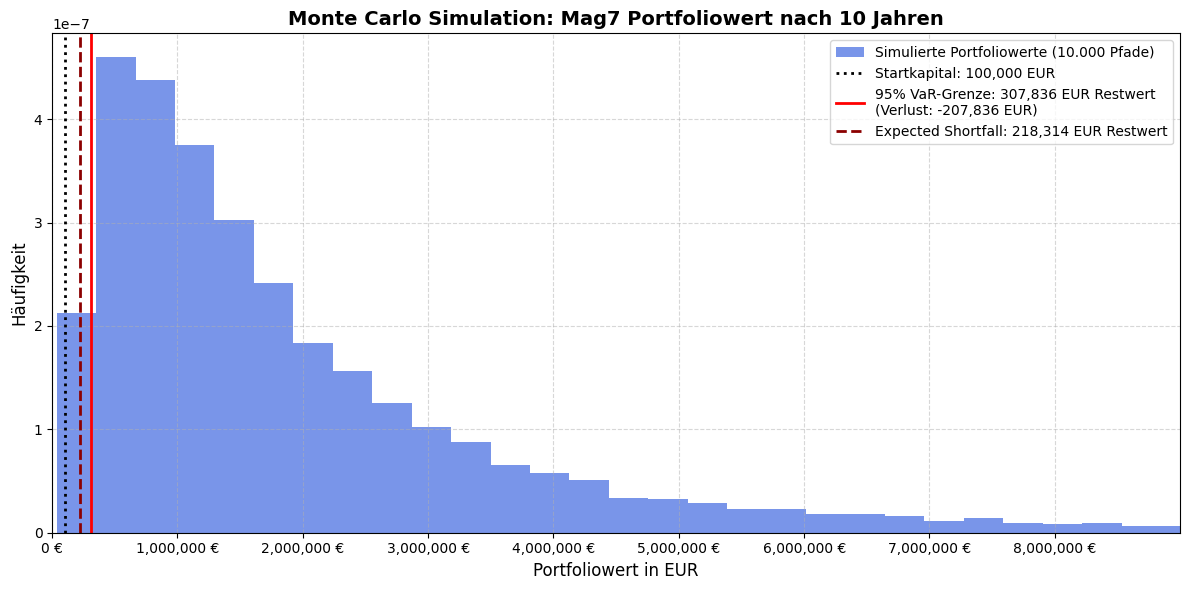

<Figure size 1000x600 with 0 Axes>

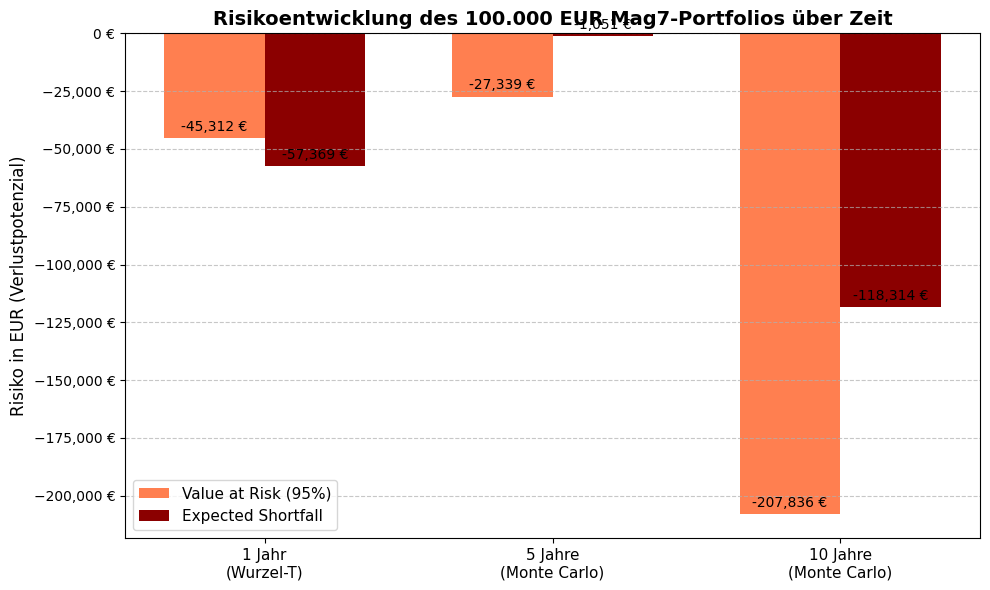

In [9]:
import matplotlib.pyplot as plt
import numpy as np

print("\n--- Phase 5: Generiere finale Präsentations-Grafiken ---")

# ==========================================
# Vorbereitung: Wir brauchen die Verteilung der 10-Jahres-Simulation 
# (Da unsere Funktion in Phase 3 nur die Endwerte ausgespuckt hat, 
# simulieren wir hier für den Plot nochmal schnell die 10.000 Pfade)
# ==========================================
simulated_log_returns_10yr = np.random.normal(mu_log, sigma_log, (trading_days_10yr, 10000))
cumulative_log_returns_10yr = simulated_log_returns_10yr.sum(axis=0)
final_portfolio_values_10yr = start_capital * np.exp(cumulative_log_returns_10yr)
simulated_losses_10yr = start_capital - final_portfolio_values_10yr

# ==========================================
# Grafik 1: Die 10-Jahres Monte Carlo Verteilung
# ==========================================
plt.figure(figsize=(12, 6))

# Histogramm der simulierten Portfoliowerte nach 10 Jahren
# Wir plotten hier die Endwerte (nicht die Verluste), um die extreme Rechtsschiefe zu zeigen
plt.hist(final_portfolio_values_10yr, bins=150, density=True, color='royalblue', alpha=0.7, 
         label='Simulierte Portfoliowerte (10.000 Pfade)')

# Markierung des Startkapitals
plt.axvline(start_capital, color='black', linestyle='dotted', linewidth=2, 
            label=f'Startkapital: {start_capital:,.0f} EUR')

# Markierung des Value at Risk (Endwert = Startkapital - VaR)
var_threshold_value = start_capital - var_10yr_sim
plt.axvline(var_threshold_value, color='red', linestyle='solid', linewidth=2, 
            label=f'95% VaR-Grenze: {var_threshold_value:,.0f} EUR Restwert\n(Verlust: {var_10yr_sim:,.0f} EUR)')

# Markierung des Expected Shortfall
es_threshold_value = start_capital - es_10yr_sim
plt.axvline(es_threshold_value, color='darkred', linestyle='dashed', linewidth=2, 
            label=f'Expected Shortfall: {es_threshold_value:,.0f} EUR Restwert')

plt.title('Monte Carlo Simulation: Mag7 Portfoliowert nach 10 Jahren', fontsize=14, fontweight='bold')
plt.xlabel('Portfoliowert in EUR', fontsize=12)
plt.ylabel('Häufigkeit', fontsize=12)
# X-Achse formatieren (Euro)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f} €'))
# Wir limitieren die X-Achse ein wenig, da einzelne extreme Ausreißer das Bild sonst stauchen
plt.xlim(0, np.percentile(final_portfolio_values_10yr, 98)) 
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# Grafik 2: Risikoentwicklung über die Zeit (1, 5, 10 Jahre)
# ==========================================
plt.figure(figsize=(10, 6))

labels = ['1 Jahr\n(Wurzel-T)', '5 Jahre\n(Monte Carlo)', '10 Jahre\n(Monte Carlo)']
var_values = [var_1yr_eur_norm, var_5yr_sim, var_10yr_sim]
es_values = [es_1yr_eur_norm, es_5yr_sim, es_10yr_sim]

x = np.arange(len(labels))
width = 0.35  # Breite der Säulen

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, var_values, width, label='Value at Risk (95%)', color='coral')
rects2 = ax.bar(x + width/2, es_values, width, label='Expected Shortfall', color='darkred')

# Beschriftung, Titel und Achsen
ax.set_ylabel('Risiko in EUR (Verlustpotenzial)', fontsize=12)
ax.set_title('Risikoentwicklung des 100.000 EUR Mag7-Portfolios über Zeit', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f} €'))
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Werte direkt über die Säulen schreiben
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:,.0f} €',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 Punkte vertikaler Offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

In [10]:
pip install streamlit yfinance pandas numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


2026-04-25 12:48:09.873 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 12:48:09.874 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-25 12:48:09.874 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 12:48:09.933 
  command:

    streamlit run /Users/julian/Documents/Python REPO /QMA-/.venv-1/lib/python3.14/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-25 12:48:09.933 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 12:48:09.933 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 12:48:09.933 Thread 'MainThread': missing ScriptRunContext! Thi

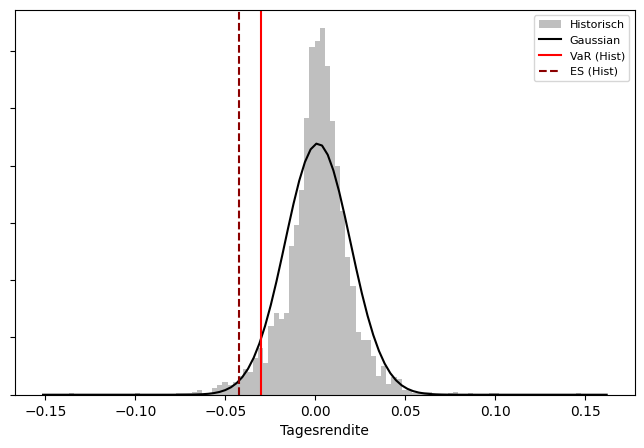

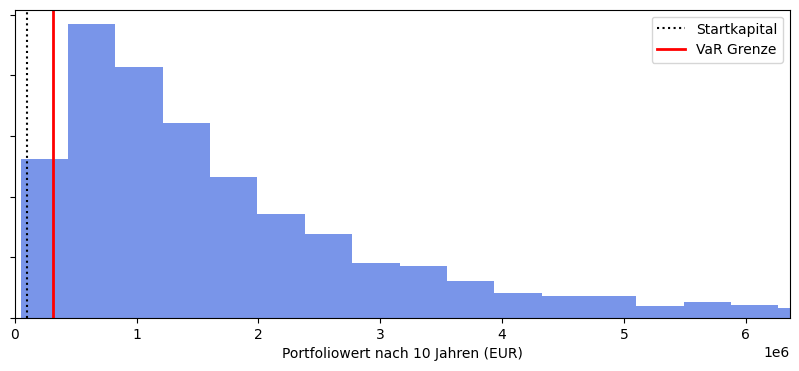

In [11]:
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ==========================================
# 1. Page Config & Caching (Performance)
# ==========================================
st.set_page_config(page_title="Mag7 Risk & Return Engine", layout="wide", page_icon="📈")

# @st.cache_data sorgt dafür, dass die Daten nur einmal heruntergeladen werden
@st.cache_data
def load_data():
    tickers = ['AAPL', 'TSLA', 'MSFT', 'META', 'AMZN', 'GOOGL', 'NVDA']
    data = yf.download(tickers, start="2016-04-01", end="2026-04-01")['Close'].dropna()
    market_data = yf.download('SPY', start="2016-04-01", end="2026-04-01")['Close'].dropna()
    return data, market_data

st.title("🚀 Magnificent 7: Risk & Return Dashboard")
st.markdown("Dieses Dashboard analysiert ein gleichgewichtetes Portfolio der 'Magnificent 7' über verschiedene Zeithorizonte und Risikomodelle.")

# Daten laden
with st.spinner("Lade historische Marktdaten..."):
    data, market_data = load_data()

# ==========================================
# 2. Sidebar (Interaktive Parameter)
# ==========================================
st.sidebar.header("⚙️ Portfolio Parameter")
start_capital = st.sidebar.number_input("Startkapital (EUR)", min_value=10000, max_value=10000000, value=100000, step=10000)

alpha_input = st.sidebar.selectbox("Konfidenzniveau (VaR)", ["95%", "99%"])
alpha = 0.05 if alpha_input == "95%" else 0.01
z_score = stats.norm.ppf(alpha)

st.sidebar.markdown("---")
st.sidebar.info("💡 **Tipp:** Ändere das Startkapital oder Konfidenzniveau, um zu sehen, wie sich die Risikokennzahlen dynamisch anpassen.")

# ==========================================
# 3. Core Calculations (Datenverarbeitung)
# ==========================================
# Renditen berechnen
returns_discrete = data.pct_change().dropna()
returns_log = np.log(data / data.shift(1)).dropna()
weights = np.array([1/7] * 7)

port_ret_discrete = returns_discrete.dot(weights)
port_ret_log = returns_log.dot(weights)

mu_norm, sigma_norm = port_ret_discrete.mean(), port_ret_discrete.std()
mu_log, sigma_log = port_ret_log.mean(), port_ret_log.std()

# 1-Tag VaR & ES
var_pct_norm = mu_norm + (z_score * sigma_norm)
var_eur_norm = start_capital * abs(var_pct_norm) # Als positiver Betrag für die Anzeige

var_pct_hist = np.percentile(port_ret_discrete, alpha * 100)
var_eur_hist = start_capital * abs(var_pct_hist)

es_pct_hist = port_ret_discrete[port_ret_discrete <= var_pct_hist].mean()
es_eur_hist = start_capital * abs(es_pct_hist)

pdf_z = stats.norm.pdf(z_score)
es_pct_norm = mu_norm - sigma_norm * (pdf_z / alpha)
es_eur_norm = start_capital * abs(es_pct_norm)

# Simulation 10 Jahre (Monte Carlo Lognormal)
trading_days_10yr = 252 * 10
simulated_log_returns = np.random.normal(mu_log, sigma_log, (trading_days_10yr, 5000))
cumulative_log_returns = simulated_log_returns.sum(axis=0)
final_portfolio_values = start_capital * np.exp(cumulative_log_returns)
simulated_losses = start_capital - final_portfolio_values
var_10yr_sim = np.percentile(simulated_losses, (1 - alpha) * 100)
tail_losses = simulated_losses[simulated_losses > var_10yr_sim]
es_10yr_sim = tail_losses.mean() if len(tail_losses) > 0 else 0

# KPIs
market_returns = market_data.pct_change().dropna()
aligned_data = pd.concat([port_ret_discrete, market_returns], axis=1).dropna()
aligned_data.columns = ['Portfolio', 'Market']

rf_rate_annual = 0.02
rf_rate_daily = rf_rate_annual / 252
rm_daily = aligned_data['Market'].mean()

sharpe_annualized = ((aligned_data['Portfolio'].mean() - rf_rate_daily) / aligned_data['Portfolio'].std()) * np.sqrt(252)
rsf_annualized = ((aligned_data['Portfolio'].mean() - rm_daily) / aligned_data['Portfolio'].std()) * np.sqrt(252)

cov_matrix = aligned_data.cov()
beta_portfolio = cov_matrix.iloc[0, 1] / cov_matrix.iloc[1, 1]
treynor_annualized = ((aligned_data['Portfolio'].mean() * 252) - rf_rate_annual) / beta_portfolio

# ==========================================
# 4. Layout: Dashboard Struktur
# ==========================================

# --- Zeile 1: Performance KPIs ---
st.subheader("📊 Performance-Kennzahlen (Annualisiert)")
col1, col2, col3, col4 = st.columns(4)
col1.metric("Sharpe Ratio", f"{sharpe_annualized:.2f}", help="Überrendite vs. Volatilität")
col2.metric("Roy's Safety First", f"{rsf_annualized:.2f}", help="Überrendite vs. S&P 500")
col3.metric("Treynor Ratio", f"{treynor_annualized:.4f}", help="Überrendite vs. Beta")
col4.metric("Portfolio Beta", f"{beta_portfolio:.2f}", help="Systematisches Risiko vs Markt")

st.markdown("---")

# --- Zeile 2: Tabellen und 1-Tages Plot ---
col_table, col_plot = st.columns([1, 1])

with col_table:
    st.subheader(f"📉 Risiko-Metriken (1-Tages Horizont)")
    st.markdown(f"**Annahme:** Was passiert an einem sehr schlechten Handelstag ({alpha_input} VaR)?")
    
    risk_data = {
        "Modell": ["Gaussian (Normalverteilung)", "Historisch (BHS)"],
        "Value at Risk": [f"- {var_eur_norm:,.0f} €", f"- {var_eur_hist:,.0f} €"],
        "Expected Shortfall": [f"- {es_eur_norm:,.0f} €", f"- {es_eur_hist:,.0f} €"]
    }
    st.table(pd.DataFrame(risk_data))
    
    st.info("Der Historische VaR nutzt reale Marktdaten und fängt extreme Börsencrashs besser ab als die theoretische Normalverteilung (Fat Tails).")

with col_plot:
    st.subheader("Verteilung der Tagesrenditen")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(port_ret_discrete, bins=100, density=True, alpha=0.5, color='gray', label='Historisch')
    
    xmin, xmax = ax.get_xlim()
    x_axis = np.linspace(xmin, xmax, 100)
    ax.plot(x_axis, stats.norm.pdf(x_axis, mu_norm, sigma_norm), color='black', label='Gaussian')
    
    ax.axvline(var_pct_hist, color='red', linestyle='solid', label='VaR (Hist)')
    ax.axvline(es_pct_hist, color='darkred', linestyle='dashed', label='ES (Hist)')
    
    ax.set_yticklabels([])
    ax.set_xlabel("Tagesrendite")
    ax.legend(fontsize=8)
    st.pyplot(fig)

st.markdown("---")

# --- Zeile 3: Langfrist-Simulation ---
st.subheader("🔮 10-Jahres Monte Carlo Simulation (Lognormal)")
st.markdown("Wir projizieren das Portfolio über 10 Jahre mit 5.000 möglichen Zukunftspfaden. Die Lognormalverteilung sorgt dafür, dass das Portfolio mathematisch nicht unter 0 € fallen kann.")

col_sim_metric, col_sim_plot = st.columns([1, 2])

with col_sim_metric:
    st.metric("10-Jahre VaR (Verlust)", f"{var_10yr_sim:,.0f} €", "Maximaler Verlust im 95% Fall", delta_color="inverse")
    st.metric("10-Jahre Expected Shortfall", f"{es_10yr_sim:,.0f} €", "Durchschnittlicher Verlust im Tail", delta_color="inverse")
    st.metric("Mittlerer Endwert (Erwartung)", f"{final_portfolio_values.mean():,.0f} €")

with col_sim_plot:
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    ax2.hist(final_portfolio_values, bins=100, density=True, color='royalblue', alpha=0.7)
    
    ax2.axvline(start_capital, color='black', linestyle='dotted', label='Startkapital')
    ax2.axvline(start_capital - var_10yr_sim, color='red', linewidth=2, label='VaR Grenze')
    
    ax2.set_xlim(0, np.percentile(final_portfolio_values, 95)) # Schneidet extreme Ausreißer rechts ab für bessere Sichtbarkeit
    ax2.set_xlabel("Portfoliowert nach 10 Jahren (EUR)")
    ax2.set_yticklabels([])
    ax2.legend()
    st.pyplot(fig2)